In [9]:
import sys
import os
import numpy as np
import pretty_midi
import torch

notebook_dir = os.getcwd()
sys.path.insert(0, os.path.abspath(os.path.join(notebook_dir, '..')))

import config as C
from lstm import MusicLSTM
from music import generate_music, notes_to_midi

In [10]:
model = MusicLSTM(
    pitch_embed_dim=C.PITCH_EMBED_DIM,
    hidden_size=C.HIDDEN_SIZE,
    num_layers=C.NUM_LAYERS,
    dropout=C.DROPOUT,
)
model.load_state_dict(torch.load(C.MODEL_PATH, map_location='cpu'))
model.eval()
print(model)

MusicLSTM(
  (pitch_embed): Embedding(128, 16)
  (lstm): LSTM(18, 256, num_layers=2, batch_first=True, dropout=0.3)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (pitch_head): Linear(in_features=256, out_features=128, bias=True)
  (step_head): Linear(in_features=256, out_features=1, bias=True)
  (dur_head): Linear(in_features=256, out_features=1, bias=True)
)


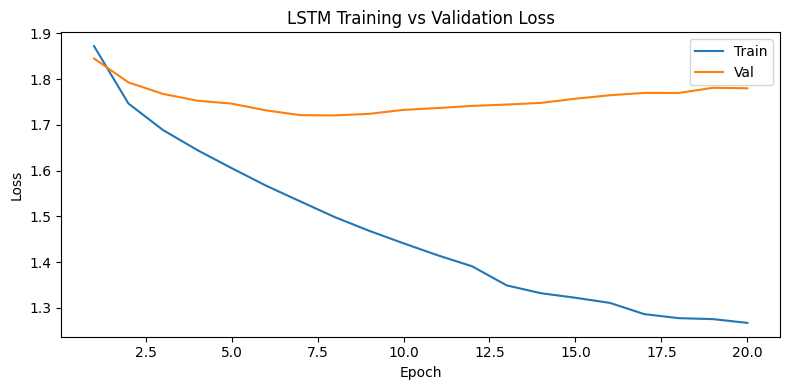

In [11]:
import json
import matplotlib.pyplot as plt

with open(C.LOSS_LOG) as f:
    log = json.load(f)

epochs = range(1, len(log["train"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, log["train"], label="Train")
plt.plot(epochs, log["val"],   label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def load_seed(midi_path, seq_length):
    pm    = pretty_midi.PrettyMIDI(midi_path)
    notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)
    prev, data = notes[0].start, []
    for n in notes:
        # log1p matches the format used during training (see data_import.py)
        data.append([n.pitch / 127.0, np.log1p(n.start - prev), np.log1p(n.end - n.start)])
        prev = n.start
    return np.array(data[:seq_length], dtype=np.float32)

seed = load_seed(C.SEED_MIDI, C.SEQ_LENGTH)

os.makedirs(os.path.dirname(C.OUTPUT_MIDI), exist_ok=True)
generated = generate_music(
    model, seed,
    num_to_generate=C.NUM_TO_GENERATE,
    temperature=C.TEMPERATURE,
    min_step=C.MIN_STEP,
    min_dur=C.MIN_DUR,
)
notes_to_midi(generated, C.OUTPUT_MIDI)
print(f"Saved to {C.OUTPUT_MIDI}")

Saved to /Users/emircalvillo/development/MyProjects/DL-Music-Generation/scripts/LSTM/generated_music/lstm_output2.mid
